# Architecture Analysis

In the previous notebook, we analyzed the roofline of the Llama 3.1 model under a given set of conditions. In this chapter, we carry out a comprehensive analysis of the target hardware, covering:

(1) performance modeling of the hardware

(2) performance analysis of the individual compute units, in particular the systolic array

(3) analysis of the bounds and latency of the system as a whole

(4) using the resulting performance model to benchmark the hardware in practice.

In [1]:
import sys
if "code" not in sys.path: sys.path.insert(0, "code")   # model modules live in code/
from tile_model import Hardware, SA1, SA2, VCPU, DMA, SRAM
from helper import plot
from analytical_model import kernel_time

## 1. Accelerator modeling

Begin by laying out the accelerator's components and the links between them, so that the byte movement and latency between them can be seen at a glance.

Note that all units are normalized to **bytes** and cycles.

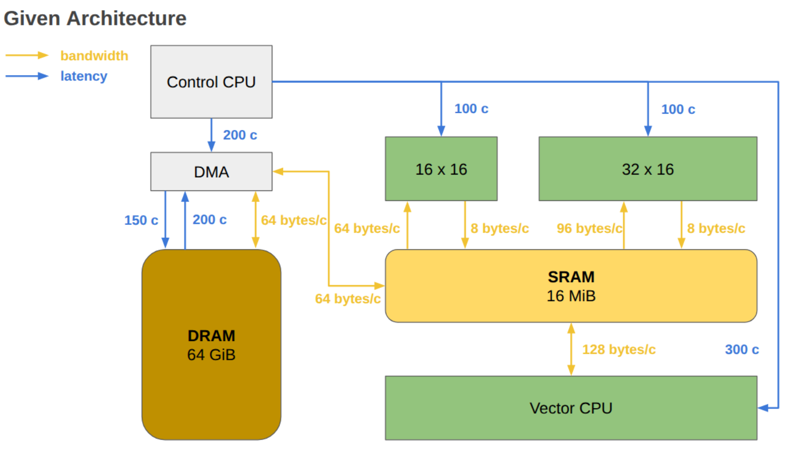

In [2]:
plot("img/architecture.png", 800)

### SA unit Theoratical performance

In the previous section we study the memory bound/

On-chip analysis. SA1 SA2 model!

### Photonic Chip: Bandwidth model

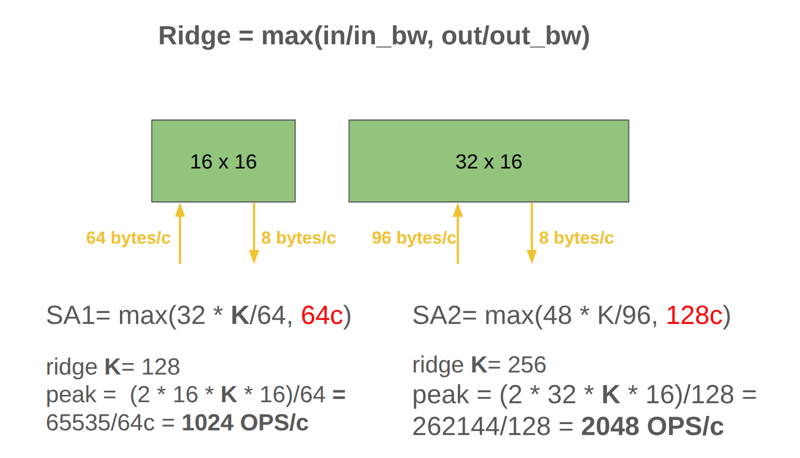

In [3]:
plot("img/SA_ridge.png", 800)

In [4]:
from tile_model import SA1, SA2

for K in [32, 64, 128, 256]:
    print(f"K={K}")
    sa1 = SA1(16, K, compute_model="bandwidth")
    print(f"sa1 macs: {sa1.macs()}, cycle:{sa1.cycle()}")

    sa2 = SA2(32, K, compute_model="bandwidth")
    print(f"sa2 macs: {sa2.macs()}, cycle:{sa2.cycle()}")

K=32
sa1 macs: 8192, cycle:64
sa2 macs: 16384, cycle:128
K=64
sa1 macs: 16384, cycle:64
sa2 macs: 32768, cycle:128
K=128
sa1 macs: 32768, cycle:64
sa2 macs: 65536, cycle:128
K=256
sa1 macs: 65536, cycle:128
sa2 macs: 131072, cycle:128


### Traditional chip (MAC model)

In [5]:
from tile_model import SA1, SA2

for K in [32, 64, 128, 256]:
    print(f"K={K}")
    sa1 = SA1(16, K, compute_model="mac")
    print(f"sa1 macs: {sa1.macs()}, cycle:{sa1.cycle()}")

    sa2 = SA2(32, K, compute_model="mac")
    print(f"sa2 macs: {sa2.macs()}, cycle:{sa2.cycle()}")

K=32
sa1 macs: 8192, cycle:64
sa2 macs: 16384, cycle:128
K=64
sa1 macs: 16384, cycle:64
sa2 macs: 32768, cycle:128
K=128
sa1 macs: 32768, cycle:128
sa2 macs: 65536, cycle:128
K=256
sa1 macs: 65536, cycle:256
sa2 macs: 131072, cycle:256


Under Two assumptions the work-load balance is different

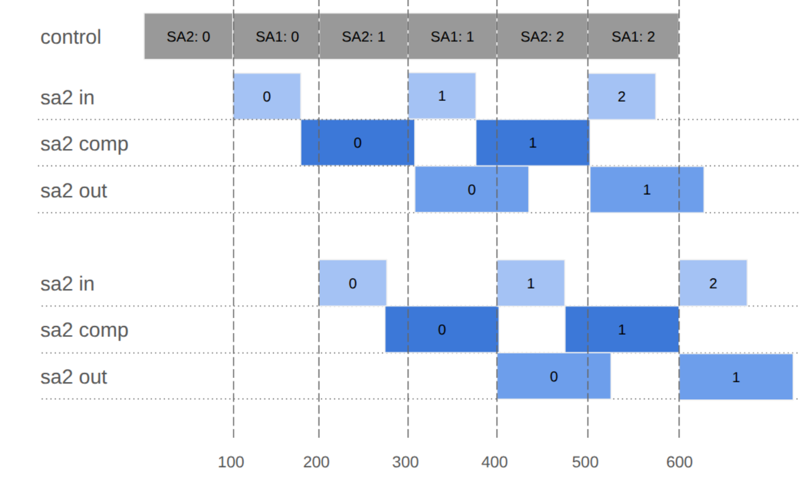

In [6]:
plot("img/control_seq.png", 800)

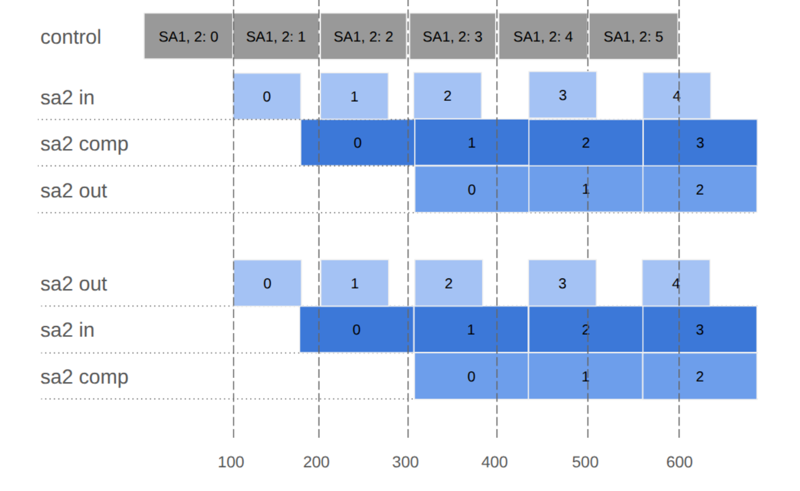

In [7]:
plot("img/control_pipeline.png", 800)


### Analytical model

To model this gap between serialized model and pipelined model, we sample a full workflow: kernel start + DRAM -> SRAM -> SA1 & SA2 -> SRAM -> SRAM -> DRAM

Cycles from control-CPU launch until the result is back in DRAM, for one kernel
on `x_bytes` of input:

```
ctrl->DMA | DRAM read | DRAM->SRAM | launch | COMPUTE | ctrl->DMA | SRAM->DRAM | DRAM write
```

`latency` = every stage serialised (one shot).
`pipelined` = chunked and double-buffered, so the slowest pipe hides the rest.

Example: For Loading 16x256 256x16 int8, running on sa1/sa2, write back to DRAM, a full cycle is written as:

In [8]:
rows, cols, K = 16, 16, 256       # operands 16x256 and 256x16, int8
BW_in, BW_out, latency = 64, 8, 100

load = (rows + cols) * K // BW_in     # in flow
mac = K                               # on chip
drain = rows * cols * 2 // BW_out     # out
stage = max(load, mac)                # the load hides under the MACs

print("serialized  ", latency + stage, "cyc/job")       # CPU blocked by each command
print("pipelined   ", stage, "cyc/job")
print("diff  ", latency, "cyc")# next command issued early

serialized   356 cyc/job
pipelined    256 cyc/job
diff   100 cyc


The entire process can be presented as a **gantt plot**

A gantt plot presents the on-chip cycle of each task and their schedular dependency. We demonstrate the previous control bound analysis with as follows:

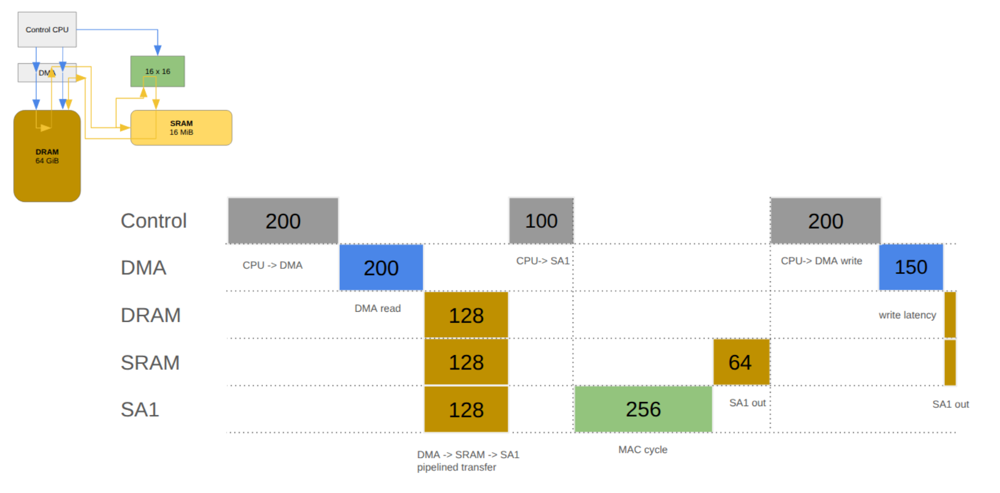

In [9]:
plot("img/schedule_model.png", 1000)

This model can be further written as callable function:

The kernel_time function will simplify the benchmarking in the next several sections

In [10]:

MB = 2 ** 20
GB = 2 ** 30

## Latency model
BW_DMA = 64                                     # DRAM -> DMA -> SRAM
BW_VCPU = 128                                   # SRAM <-> vector CPU
PORTS = {"sa16": [(16, 64, 8)],                 # (rows, in B/cyc, out B/cyc)
         "sa32": [(32, 96, 8)],
         "both": [(16, 64, 8), (32, 96, 8)]}

byte_list = [16 * MB]
device_list = ["sa16", "sa32", "both"]
K1_list = [32, 64, 128, 256]
K2_list = [32, 64, 128, 256]

print(f"{'size':>8} {'device':>7} {'K1/K2':>9} {'transfer':>12} {'compute':>12} "
      f"{'total':>13} {'transfer%':>10}")
print("-" * 78)

for x in byte_list:
    for unit in device_list:
        # both arrays -> sweep a depth for each; a single array has only K1
        pairs = ([(k1, k2) for k1 in K1_list for k2 in K2_list] if unit == "both"
                 else [(k1, None) for k1 in K1_list])
        for K1, K2 in pairs:
            r = kernel_time(x, unit, K1, K2)
            transfer = r["load"] + r["store"]      # DRAM->SRAM  +  SRAM->DRAM
            compute = r["compute"]
            total = r["latency"]                   # transfer + compute + LAT
            label = f"{K1}/{K2}" if K2 is not None else f"{K1}"
            print(f"{x // MB:>6}MB {unit:>7} {label:>9} {transfer:>12,.0f} {compute:>12,.0f} "
                  f"{total:>13,.0f} {100 * transfer / total:>9.2f}%")
        print("-" * 78)

    size  device     K1/K2     transfer      compute         total  transfer%
------------------------------------------------------------------------------
    16MB    sa16        32      393,216    1,048,576     1,442,642     27.26%
    16MB    sa16        64      327,680      524,288       852,818     38.42%
    16MB    sa16       128      294,912      262,144       557,906     52.86%
    16MB    sa16       256      278,528      262,144       541,522     51.43%
------------------------------------------------------------------------------
    16MB    sa32        32      436,907    1,398,101     1,835,858     23.80%
    16MB    sa32        64      349,525      699,051     1,049,426     33.31%
    16MB    sa32       128      305,835      349,525       656,210     46.61%
    16MB    sa32       256      283,989      174,763       459,602     61.79%
------------------------------------------------------------------------------
    16MB    both     32/32      411,941      599,186     1,01

## 2. Automatic first principle performance model



### Structure

`code/tile_model.py` is the machine itself: one small class per unit, and no numerics anywhere.
Each call takes a request — a shape, a dtype, a direction — and returns **cycles**.

**`Hardware`** is a frozen dataclass holding every constant in one place:
`dma_bw=64`, `vector_bw=128`, `dma_setup=200`, `dram_read_latency=200`,
`dram_write_latency=150`, `vector_launch=300`, `array_latency=100`,
plus the switches `control`, `array_model` and `arithmetic`.
Every other class takes `hw=` and reads its numbers from there, so a what-if
experiment is one replaced field, never an edit to a formula.

**`DMA`** moves bytes between DRAM and SRAM:

    transfer(shape, dtype, 'read' | 'write')  =  dma_setup + DRAM latency + bytes / dma_bw

**`SA1` and `SA2`** are the two systolic arrays: 16 and 32 rows, 16 output columns each,
operands in at 64 and 96 B/cycle, and results out at 8 B/cycle on both.

    compute(rows, K, dtype)  =  array_latency + max(operands in, MACs) + drain

The three parts are callable on their own — `input_cycles()`, `compute_cycles()`,
`output_cycles()` — which is how the bottleneck becomes visible.

**`VCPU`** is the vector unit, charged purely by the bytes it touches:

    compute(shape, in_dtype, out_dtype, read_passes, write_passes)
        =  vector_launch + (read bytes + write bytes) / vector_bw

**`SRAM`** is the one class that returns no cycles. `allocate(name, shape, dtype)` and
`free(name)` track live buffers, raise `MemoryError` past 16 MiB, and record `peak_bytes`.


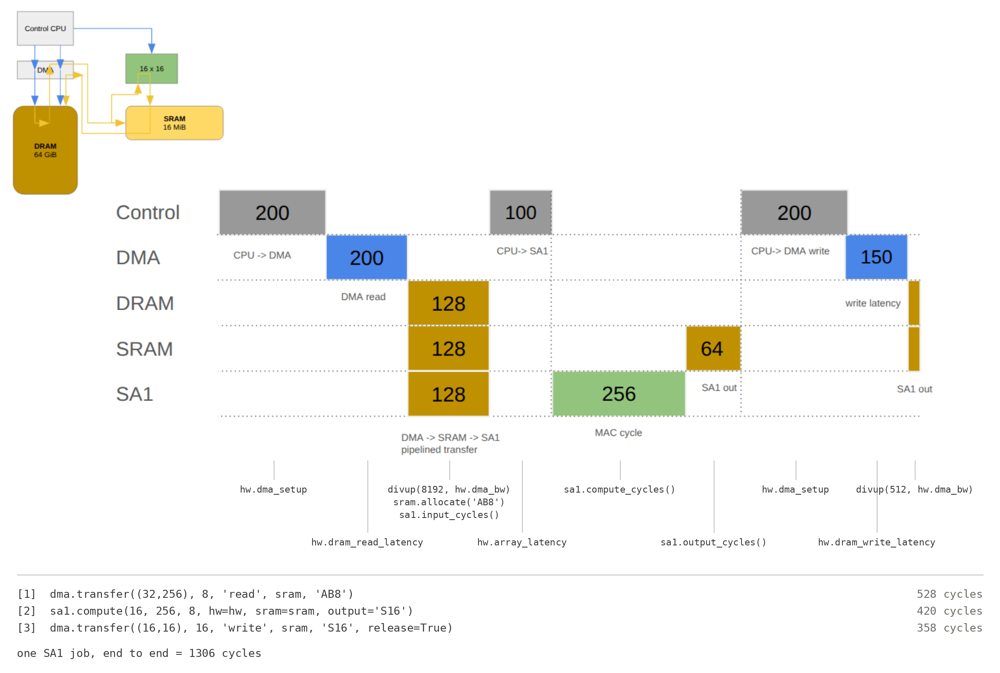

In [11]:
plot("img/schedule_model_api.png", 1000)

In [12]:
from tile_model import Hardware, SA1, DMA, SRAM

hw = Hardware()
sram, dma, sa1, sa2 = SRAM(hw=hw), DMA(hw=hw), SA1(), SA2()

# [1] both operands (16x256 and 256x16 int8 = 8192 B) in one stream
load = dma.transfer((32, 256), 8, 'read', sram, 'AB8')
# [2] command latency + MACs + output drain
job = sa1.compute(16, 256, 8, hw=hw, sram=sram, output='S16')
# [3] the 16x16 int16 result (512 B) back to DRAM
store = dma.transfer((16, 16), 16, 'write', sram, 'S16', release=True)

print( "*" * 12, "SA1", "*" * 12)
print("load ", load, "cycles")
print("job  ", job, "cycles")
print("store", store, "cycles")
print("total", load + job + store, "cycles")


#################### SA2
load = dma.transfer((64, 256), 8, 'read', sram, 'sa28')
job = sa2.compute(32, 256, 8, hw=hw, sram=sram, output='S16')
store = dma.transfer((32, 16), 16, 'write', sram, 'S16', release=True)

print( "*" * 12, "SA2", "*" * 12)
print("load ", load, "cycles")
print("job  ", job, "cycles")
print("store", store, "cycles")
print("total", load + job + store, "cycles")

************ SA1 ************
load  528 cycles
job   420 cycles
store 358 cycles
total 1306 cycles
************ SA2 ************
load  656 cycles
job   484 cycles
store 366 cycles
total 1506 cycles


### Using performance model recheck SA1 SA2 performance

In [13]:
hw = Hardware()
sa1, sa2 = SA1(), SA2()
dma, vcpu, sram = DMA(hw=hw), VCPU(hw=hw), SRAM(hw=hw)

sa1.compute(16, 128, 8)

dma.transfer((16, 128), 16, 'read', sram, 'Q16')

vcpu.transform(sram, 'Q16', 'Q8', 8,
                        read_passes=2, free_input=True)


for sa, name in ((SA1(), 'SA1'), (SA2(), 'SA2')):
  for K in (128, 256):
      job = type(sa)(K=K)
      print(f'{name} K={K}: input {job.input_cycles()} cyc, compute {job.compute_cycles()} cyc, drain {job.output_cycles()} cyc, '
            f'+100 command -> period {100+max(job.input_cycles(), job.compute_cycles())} cyc, {job.macs()} MACs')

SA1 K=128: input 64 cyc, compute 128 cyc, drain 64 cyc, +100 command -> period 228 cyc, 32768 MACs
SA1 K=256: input 128 cyc, compute 256 cyc, drain 64 cyc, +100 command -> period 356 cyc, 65536 MACs
SA2 K=128: input 64 cyc, compute 128 cyc, drain 128 cyc, +100 command -> period 228 cyc, 65536 MACs
SA2 K=256: input 128 cyc, compute 256 cyc, drain 128 cyc, +100 command -> period 356 cyc, 131072 MACs


### Performance analysis


    16MB    both   256/256      281,805      104,858       387,512     72.72%

**1. The transfer proportion is a bottleneck readout.** 72.72% (both, K=256)
  means the kernel is transfer-dominated and widening DRAM would help.
  23.80% (sa32, K=32) means it's compute-dominated and DRAM is irrelevant.
  The proportion moves from 24% to 73% purely from choosing K and the device
  — same bytes, same work.

    16777216B      sa16  256    278,528.0    262,144.0    541,522.0     51.43%

The size column barely matters once past the fixed latency: 16 and 32MiB give nearly identical percentages (58.88 / 58.93),
  because both transfer and compute scale linearly. K and device are the
  real variables in this sweep; x mostly is not.

    16MB    sa16       128      294,912      262,144       557,906     52.86%
    16MB    sa16       256      278,528      262,144       541,522     51.43%

**2. The 8 B/c output port is the bottleneck.** Inputs come in at
  64–96 B/c and DMA at 64, but results leave at 8. the "compute" column is pure port time.

**3. K >= 128 Memory bound, <= computation bound**



### Conclusion

**Bandwidth model — the output drain is the floor.** With compute free, a job costs `max(input, drain)`. The drain is fixed at 512 B (SA1) / 1024 B (SA2) over a common 8 B/c port -> 64 / 128 cycles *independent of K*, while the input takes K/2 cycles on both arrays. So SA1 is drain-bound below K=128 and input-bound above it; SA2 stays drain-bound all the way to K=256, where the two ports tie. Shallow reductions pay for a drain they cannot fill.

**MAC model — the reduction depth is the floor.** `BW_in` is provisioned so that the input costs `(rows+16)·K / BW_in` = K/2 cycles on *both* arrays (32K/64 and 48K/96), exactly half the K cycles of MAC streaming, so the input port never binds. A job costs 100 (command) + K, and the drain hides behind the next job: 228 cycles at K=128, 356 at K=256, on either array. The ceiling is 552 MAC/cycle at K=256 (SA1 184 + SA2 368) and 431 at K=128 — set by the command latency and by K, not by a port.

**SA2's extra silicon buys nothing until K≥128**

Quantization overflow: int8 -> int16 encountered overflow, especially in sa. int 8 2**7 * K (2**) <= int16 2**15. If K=256,

### Why the two arrays differ

**The drain is the only structural asymmetry.** `BW_in` scales with the array (64 -> 96 B/c), which keeps the input at K/2 cycles for both, but both arrays drain through the same 8 B/c port — so SA2's 2x outputs take 2x longer to evacuate. That is exactly why SA2's extra silicon buys nothing until K>=128: at K=64 it does 2x the MACs in 2x the cycles, 256 MAC/cycle either way.

**That comparison is per job cycle, though.** Once the 100-cycle serialized command latency is counted, SA2 is still 2x better even at K=64 (199.8 vs 99.9 MAC/cycle), because the fixed overhead amortizes over twice the MACs. The array only truly "buys nothing" when commands are free (`control='pipelined'`).